In [1]:
import numpy as np
from gpcam import GPOptimizer

import pandas as pd

from sklearn.datasets import load_digits

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

import warnings
# Add this at the top of your code or before running experiments
warnings.filterwarnings("ignore", message="No noise function or measurement noise provided.*")

from scipy.spatial.distance import cdist


# Load the Data

In [2]:
print("="*70)
print("Step 1: Loading and normalizing full dataset")
print("="*70)

digits = load_digits()
X_full = digits.data.copy()
numerical_values = digits.target

# Convert to binary classification
y_full = (numerical_values >= 5).astype(int)

# Normalize ALL data to probability distributions
print(f"\nNormalizing {len(X_full)} samples...")
for i in range(len(X_full)):
    X_full[i] = (X_full[i] - np.min(X_full[i])) + 1e-8
    X_full[i] = X_full[i] / np.sum(X_full[i])

print(f"✅ Full dataset: {X_full.shape}")
print(f"✅ Binary labels: {y_full.shape}")

Step 1: Loading and normalizing full dataset

Normalizing 1797 samples...
✅ Full dataset: (1797, 64)
✅ Binary labels: (1797,)


# GP Model Components

In [3]:
import numpy as np
from sklearn.datasets import load_digits
from scipy.stats import wasserstein_distance
from scipy.spatial.distance import cdist as scipy_cdist
import ot

# ===== DISTANCE FUNCTIONS =====
def KL(p, q, eps=1e-10):
    p_safe = np.clip(p, eps, None)
    q_safe = np.clip(q, eps, None)
    return np.sum(p_safe * np.log(p_safe / q_safe))

def JS_divergence(p, q, eps=1e-10):
    p_safe = np.clip(p, eps, None)
    q_safe = np.clip(q, eps, None)
    M = 0.5 * (p_safe + q_safe)
    js = 0.5 * (KL(p_safe, M, eps) + KL(q_safe, M, eps))
    return np.maximum(js, 0.0)

def wasserstein_2d(p, q):
    positions = np.array([[i, j] for i in range(8) for j in range(8)])
    M = scipy_cdist(positions, positions, metric='euclidean')
    return ot.emd2(p, q, M)

def sliced_wasserstein(p, q, n_projections=50):
    """
    Sliced Wasserstein distance between two distributions
    
    Args:
        p, q: flattened distributions (64,)
        n_projections: number of random projections (more = more accurate but slower)
    """
    positions = np.array([[i, j] for i in range(8) for j in range(8)])
    
    # Sliced Wasserstein uses positions as features
    sw_dist = ot.sliced_wasserstein_distance(
        positions, positions,
        p, q,
        n_projections=n_projections,
        seed=42  # For reproducibility
    )
    
    return sw_dist

def gromov_wasserstein(p, q):
    # Structure based on intensity relationships only
    p_features = p.reshape(-1, 1)
    q_features = q.reshape(-1, 1)
    
    C1 = scipy_cdist(p_features, p_features, metric='euclidean')
    C2 = scipy_cdist(q_features, q_features, metric='euclidean')
    
    p_weights = p / p.sum()
    q_weights = q / q.sum()
    
    return ot.gromov.gromov_wasserstein2(
        C1, C2, p_weights, q_weights, 
        loss_fun='square_loss', log=False
    )

def fused_gromov_wasserstein(p, q, alpha=0.5):
    positions = np.array([[i, j] for i in range(8) for j in range(8)])
    
    # Feature distance: pixel intensities
    p_features = p.reshape(-1, 1)
    q_features = q.reshape(-1, 1)
    M = scipy_cdist(p_features, q_features, metric='euclidean')
    
    # Structure: spatial positions
    C1 = scipy_cdist(positions, positions, metric='euclidean')
    C2 = scipy_cdist(positions, positions, metric='euclidean')
    
    p_weights = p / p.sum()
    q_weights = q / q.sum()
    
    return ot.gromov.fused_gromov_wasserstein2(
        M, C1, C2, p_weights, q_weights,
        loss_fun='square_loss', alpha=alpha, log=False
    )

def compute_distance_matrix(X, distance_func, name=""):
    n = X.shape[0]
    D_matrix = np.zeros((n, n))
    
    print(f"Computing {name} distance matrix ({n}x{n})...")
    for i in range(n):
        if i % 100 == 0:
            print(f"  Row {i}/{n}...")
        for j in range(i, n):  # Only compute upper triangle + diagonal
            dist = distance_func(X[i], X[j])
            D_matrix[i, j] = dist
            D_matrix[j, i] = dist  # Symmetric
    
    return D_matrix


# # ===== COMPUTE AND SAVE ALL DISTANCE MATRICES =====
# print("\n" + "="*70)
# print("Step 2: Computing and saving distance matrices")
# print("="*70)

# distance_metrics = {
# #     'JS': JS_divergence,
# #     'Wass2D': wasserstein_2d,
# #     'GW': gromov_wasserstein,
# #     'FGW': fused_gromov_wasserstein,
#       'sliced_Wass': sliced_wasserstein,
#  }

# for name, func in distance_metrics.items():
#     print(f"\n{'='*70}")
#     D = compute_distance_matrix(X_full, func, name=name)
    
#     filename = f'digits_distance_{name}.npy'
#     np.save(filename, D)
    
#     print(f"✅ Saved: {filename}")
#     print(f"   Shape: {D.shape}")
#     print(f"   Min: {np.min(D):.6f}, Max: {np.max(D):.6f}")
#     print(f"   Memory: {D.nbytes / 1e6:.2f} MB")

# # Also save the full normalized data and labels
# np.save('digits_X_full_normalized.npy', X_full)
# np.save('digits_y_full.npy', y_full)

# print("\n" + "="*70)
# print("✅ ALL DISTANCE MATRICES SAVED!")
# print("="*70)
# print("\nSaved files:")
# print("  - digits_distance_JS.npy")
# print("  - digits_distance_Wass1D.npy")
# print("  - digits_distance_Wass2D.npy")
# print("  - digits_distance_GW.npy")
# print("  - digits_X_full_normalized.npy")
# print("  - digits_y_full.npy")

In [31]:

from sklearn.model_selection import train_test_split

# ===== LOAD PRECOMPUTED MATRICES =====
print("="*70)
print("Loading precomputed data and distances")
print("="*70)

# Choose which distance metric to use
DISTANCE_METRIC = 'Wass2D'  # Options: 'JS', 'Wass2D', 'GW', 'FGW', 'sliced_Wass'

distance_full = np.load(f'digits_distance_{DISTANCE_METRIC}.npy')
print(f"✅ Loaded {DISTANCE_METRIC} distance matrix: {distance_full.shape}")

if DISTANCE_METRIC=='GW':
    distance_full = distance_full*1e5

# ===== SPLIT INTO TRAIN/TEST =====
print("\n" + "="*70)
print("Splitting into train/test and extracting submatrices")
print("="*70)


# Split indices (not data directly)
indices = np.arange(len(X_full))
train_idx_unsorted, test_idx_unsorted = train_test_split(indices, test_size=0.4, random_state=42, stratify=y_full)

# Sort indices to preserve original order
train_idx = np.sort(train_idx_unsorted)
test_idx = np.sort(test_idx_unsorted)

print(f"✅ Train indices (sorted): {train_idx[:10]}...")  # Show first 10
print(f"✅ Test indices (sorted): {test_idx[:10]}...")

# # Extract train and test data (now in original order)
# X_train = X_full[train_idx]
# X_test = X_full[test_idx]
y_train = y_full[train_idx]
y_test = y_full[test_idx]

# Use the sorted indices as "features"
X_train = train_idx.reshape(-1, 1)  # Shape: (n_train, 1)
X_test = test_idx.reshape(-1, 1)    # Shape: (n_test, 1)

print(f"X_train_gp shape: {X_train.shape}")
print(f"X_test_gp shape: {X_test.shape}")
print(f"y_train_binary shape: {y_train.shape}")


Loading precomputed data and distances
✅ Loaded Wass2D distance matrix: (1797, 1797)

Splitting into train/test and extracting submatrices
✅ Train indices (sorted): [ 0  2  3  6  7 10 11 12 14 18]...
✅ Test indices (sorted): [ 1  4  5  8  9 13 15 16 17 19]...
X_train_gp shape: (1078, 1)
X_test_gp shape: (719, 1)
y_train_binary shape: (1078,)


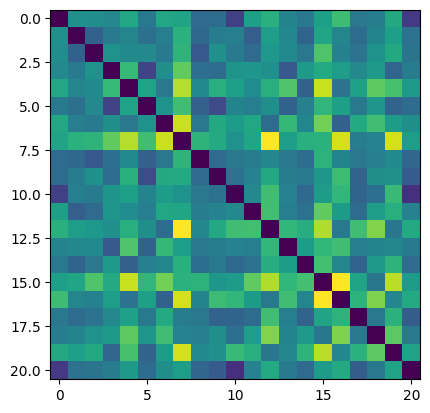

In [26]:
plt.imshow(distance_full[0:21,0:21])

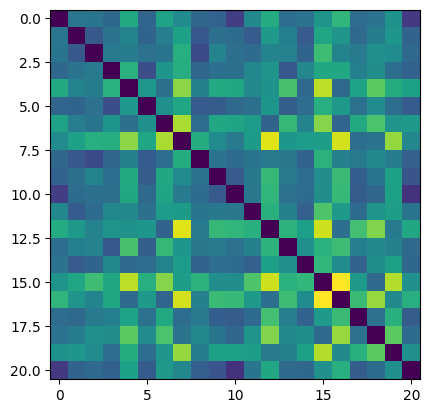

In [30]:
plt.imshow(distance_full[0:21,0:21])

In [25]:
distance_full[[0,10,20],[0,10,20]]

array([0., 0., 0.])

In [ ]:
plt.imshow(distance_full[[0,10,20],[0,10,20]])

AttributeError: 'list' object has no attribute 'reshape'

In [21]:
np.sum(X_full[1])

np.float64(0.9999999999999997)

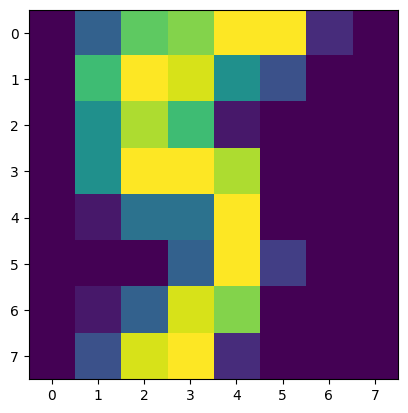

In [27]:
plt.imshow(X_full[15].reshape(8,8))

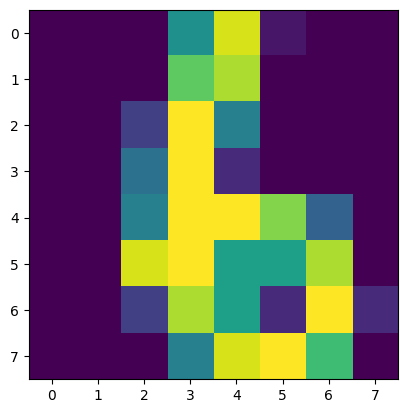

In [28]:
plt.imshow(X_full[16].reshape(8,8))

In [16]:
numerical_values[0:20]

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [32]:
from sklearn.model_selection import train_test_split

# ===== LOAD PRECOMPUTED MATRICES =====
print("="*70)
print("Loading precomputed data and distances")
print("="*70)

# Choose which distance metric to use
DISTANCE_METRIC = 'sliced_Wass'  # Options: 'JS', 'Wass2D', 'GW', 'FGW', 'sliced_Wass'

distance_full_sliced = np.load(f'digits_distance_{DISTANCE_METRIC}.npy')
print(f"✅ Loaded {DISTANCE_METRIC} distance matrix: {distance_full_sliced.shape}")

if DISTANCE_METRIC=='GW':
    distance_full_sliced = distance_full_sliced*1e5

# ===== SPLIT INTO TRAIN/TEST =====
print("\n" + "="*70)
print("Splitting into train/test and extracting submatrices")
print("="*70)


# Split indices (not data directly)
indices = np.arange(len(X_full))
train_idx_unsorted, test_idx_unsorted = train_test_split(indices, test_size=0.4, random_state=42, stratify=y_full)

# Sort indices to preserve original order
train_idx = np.sort(train_idx_unsorted)
test_idx = np.sort(test_idx_unsorted)

print(f"✅ Train indices (sorted): {train_idx[:10]}...")  # Show first 10
print(f"✅ Test indices (sorted): {test_idx[:10]}...")

# # Extract train and test data (now in original order)
# X_train = X_full[train_idx]
# X_test = X_full[test_idx]
y_train = y_full[train_idx]
y_test = y_full[test_idx]

# Use the sorted indices as "features"
X_train = train_idx.reshape(-1, 1)  # Shape: (n_train, 1)
X_test = test_idx.reshape(-1, 1)    # Shape: (n_test, 1)

print(f"X_train_gp shape: {X_train.shape}")
print(f"X_test_gp shape: {X_test.shape}")
print(f"y_train_binary shape: {y_train.shape}")

Loading precomputed data and distances
✅ Loaded sliced_Wass distance matrix: (1797, 1797)

Splitting into train/test and extracting submatrices
✅ Train indices (sorted): [ 0  2  3  6  7 10 11 12 14 18]...
✅ Test indices (sorted): [ 1  4  5  8  9 13 15 16 17 19]...
X_train_gp shape: (1078, 1)
X_test_gp shape: (719, 1)
y_train_binary shape: (1078,)


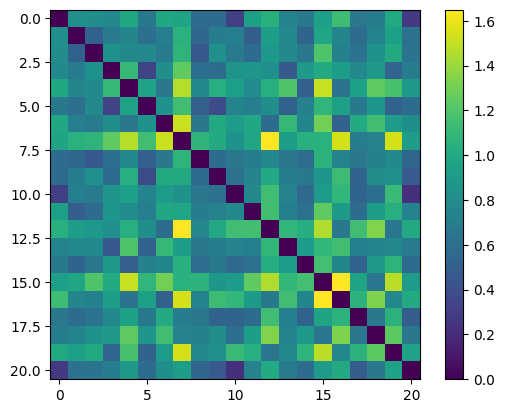

In [36]:
im = plt.imshow(distance_full[0:21,0:21])
plt.colorbar(im)

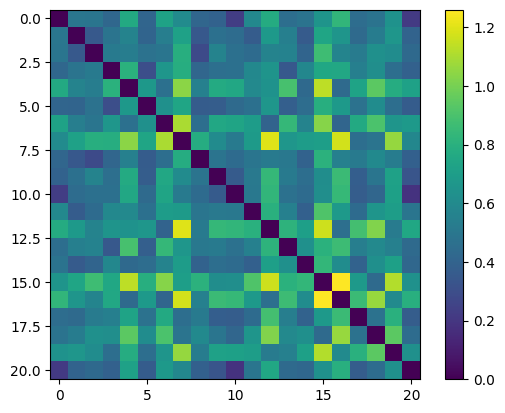

In [37]:
im = plt.imshow(distance_full_sliced[0:21,0:21])
plt.colorbar(im)

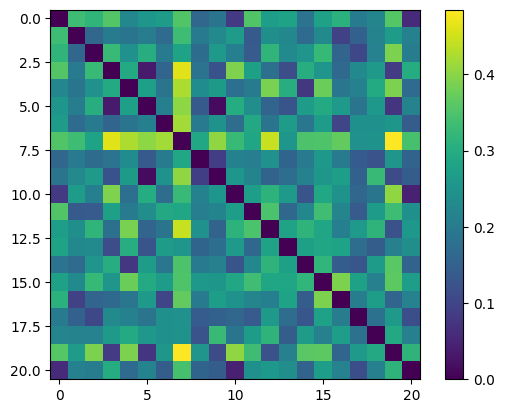

In [35]:
distance_diff = distance_full - distance_full_sliced

im = plt.imshow(distance_diff[0:21,0:21])
plt.colorbar(im)

In [22]:
# Step 2: Define the basic GP components

def bump(d, r, beta, ampl):
    """
    Bump function for the kernel
    d: distances (can be any shape)
    r: radius parameter. Identifies the cutoff after which the covariance becomes 0 when beta=0
    beta: shape parameter. 0 results in a square-like function, larger values cause faster decay
    ampl: amplitude
    """
    a = 1.0 - (d**2 / r**2)
    bump_values = np.zeros_like(a)
    
    # Only compute where a > 0
    positive_mask = a > 0.0
    if np.any(positive_mask):
        #beta = 0.1
        e = np.exp((-beta / a[positive_mask]) + beta)
        bump_values[positive_mask] = ampl * e
    
    return bump_values


def bump_k(x1, x2, hps):
    
    # x1 and x2 ARE the indices - just extract them
    x1_idx = x1.astype(int).flatten()
    x2_idx = x2.astype(int).flatten()
    
    d1 = distance_full[np.ix_(x1_idx, train_idx)]  # Shape: (len(x1), n_train)
    d2 = distance_full[np.ix_(x2_idx, train_idx)]  # Shape: (len(x2), n_train)
    
    # Apply bump to create embedding
    # phi_x1[i, :] = embedding of x1[i] based on distances to all training points
    phi_x1 = bump(d1, hps[1], beta=1, ampl=1.0)  # Shape: (len(x1), n_train)
    phi_x2 = bump(d2, hps[1], beta=1, ampl=1.0)  # Shape: (len(x2), n_train)
    
    # RBF on embeddings
    D_mat = cdist(phi_x1, phi_x2, metric='euclidean')  # Shape: (len(x1), len(x2))
    
    kernel_matrix = hps[0] * np.exp(-D_mat**2 / hps[2])
    
    return kernel_matrix


def my_noise(x, hps):
    s = np.ones(len(x)) * 1e-6  # FIXED: was 10^-5
    return np.diag(s)

def my_mean(x, hps):
    m = np.ones(len(x)) * 0
    return m


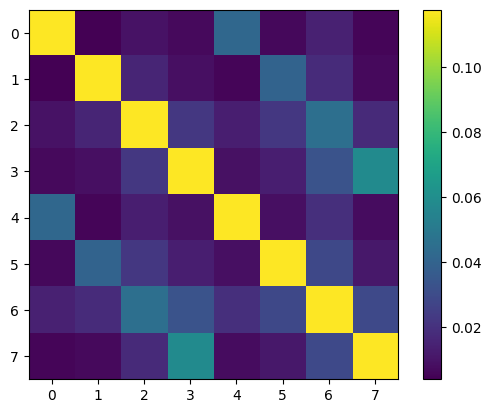

In [23]:
x1 = X_train
x2 = X_train

x1 = np.array([0,1,2,3,10,11,12,13])
x2 = np.array([0,1,2,3,10,11,12,13])

final_hps = np.array( [ 0.11755799,  0.26090964, 14.99962975])

# x1 and x2 ARE the indices - just extract them
x1_idx = x1.astype(int).flatten()
x2_idx = x2.astype(int).flatten()

d1 = distance_full[np.ix_(x1_idx, train_idx)]  # Shape: (len(x1), n_train)
d2 = distance_full[np.ix_(x2_idx, train_idx)]  # Shape: (len(x2), n_train)

# Apply bump to create embedding
# phi_x1[i, :] = embedding of x1[i] based on distances to all training points
phi_x1 = bump(d1, final_hps[1], beta=1, ampl=1.0)  # Shape: (len(x1), n_train)
phi_x2 = bump(d2, final_hps[1], beta=1, ampl=1.0)  # Shape: (len(x2), n_train)

# RBF on embeddings
D_mat = cdist(phi_x1, phi_x2, metric='euclidean')  # Shape: (len(x1), len(x2))

kernel_matrix = final_hps[0] * np.exp(-D_mat**2 / final_hps[2])


im = plt.imshow(kernel_matrix[0:20,0:20])
plt.colorbar(im)


# Running One GP model training

In [ ]:
# Now set bounds safely

# 2. Bump radius (hps[1]): [min distance, maximum distance]
train_geodesic = distance_full[np.ix_(X_train.flatten(), X_train.flatten())]
non_zero_dists = train_geodesic[train_geodesic > 0]

# Define hyperparameter bounds
bounds = np.empty((3, 2))
bounds[0] = np.array([1e-3, 1])                                              # sigma_f: signal variance      
bounds[1] = np.array([np.min(non_zero_dists), np.max(non_zero_dists)])       # length_scale: bump radius
bounds[2] = np.array([0.01, 60 ])# 15                                          # length_scale for RBF on embeddings 

print(f"\nHyperparameter bounds:")
print(f"  Signal variance: [{bounds[0, 0]:.6f}, {bounds[0, 1]:.6f}]")
print(f"  Bump radius:     [{bounds[1, 0]:.6f}, {bounds[1, 1]:.6f}]")
print(f"  RBF length:      [{bounds[2, 0]:.6f}, {bounds[2, 1]:.6f}]")

# 40% testing data, FGW distance
# With lengthscale up to 30, trained hps is 28.9 and Brier Score: 0.1633, Accuracy: 0.6912
# With lengthscale up to 60, trained hps is 29.01 and Brier Score: 0.1633, Accuracy: 0.6912



Hyperparameter bounds:
  Signal variance: [0.001000, 1.000000]
  Bump radius:     [0.000000, 2.703822]
  RBF length:      [0.010000, 60.000000]


In [35]:
# Step 4: Configure hyperparameters and initialize GPOptimizer

# # Define hyperparameter bounds
# bounds = np.empty((3, 2))
# bounds[0] = np.array([0.001, 1e4])     # sigma_f: signal variance      
# bounds[1] = np.array([0.5, 1e2])       # length_scale: bump radius
# bounds[2] = np.array([1, 1e4])         #  beta

# Initial hyperparameters (middle of bounds)
init_hps = np.mean(bounds, axis=1)
print(f"\nInitial hyperparameters: {init_hps}")

my_gpo = GPOptimizer(X_train, y_train,
                     init_hyperparameters=init_hps,
                     kernel_function=bump_k,
                     prior_mean_function=my_mean, 
                     noise_function=my_noise,
                        )

initial_log_likelihood = my_gpo.log_likelihood(init_hps)
print(f"Initial log likelihood: {initial_log_likelihood:.6f}")


# Step 5: Train the GP model
my_gpo.train(hyperparameter_bounds=bounds, init_hyperparameters=init_hps, method='global') #, max_iter=10000)


# Get optimized hyperparameters
final_hps = my_gpo.get_hyperparameters()
final_ll = my_gpo.log_likelihood(final_hps)
print(f"Final hyperparameters:   {final_hps}")
print(f"Final log likelihood:    {final_ll:.2f}")



Initial hyperparameters: [ 0.5005      1.35191124 30.005     ]
Initial log likelihood: -624.839847
Final hyperparameters:   [ 0.14892458  0.29686607 29.01515153]
Final log likelihood:    120.14


In [36]:
# Wass 2D
# Final hyperparameters:   [ 0.12658894  0.62859485 14.99988416]
# Final log likelihood:    527.65

# Fused GW
# Final hyperparameters:   [ 0.11755799  0.26090964 14.99962975]
# Final log likelihood:    129.50

# Sliced Wass
# Final hyperparameters:   [ 0.28960577  0.44475094 14.99968088]
# Final log likelihood:    374.40

# GW


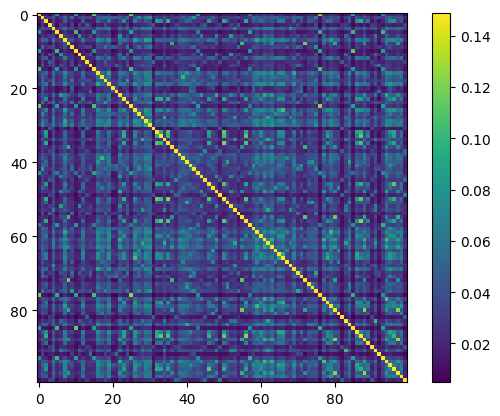

In [37]:
my_k = bump_k(X_train,X_train,final_hps)
im = plt.imshow(my_k[0:100,0:100])
plt.colorbar(im)

RMSE: 5.461846675749505e-06


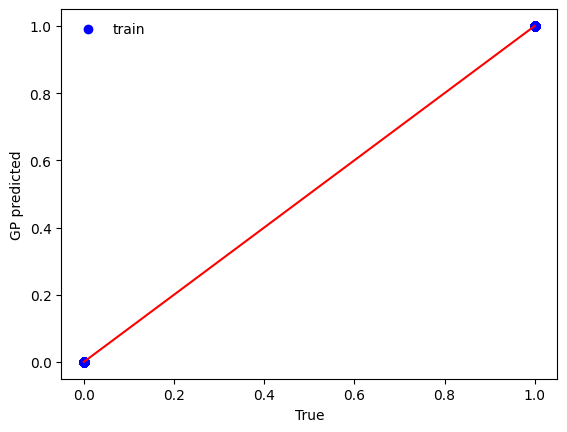

In [38]:
f_train = my_gpo.posterior_mean(X_train)["m(x)"]

my_line = np.linspace(np.min(y_train),np.max(y_train),10)

print('RMSE:', my_gpo.rmse(X_train,y_train)) # *100/np.mean(y_train),'%')

plt.scatter(y_train,f_train,color="blue",label = 'train')
plt.plot(my_line,my_line,c="red")
plt.xlabel("True")
plt.ylabel("GP predicted")
plt.legend(frameon = False)
plt.show()

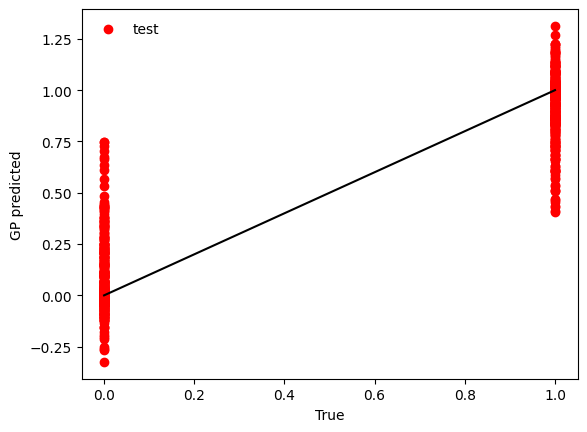

In [39]:
f = my_gpo.posterior_mean(X_test)["m(x)"]
posterior_var = my_gpo.posterior_covariance(X_test, variance_only=True, add_noise=False) # it does not matter if we added noise because it is 1e-6
var = posterior_var["v(x)"].flatten()

my_line = np.linspace(np.min(y_test),np.max(y_train),10)

plt.scatter(y_test,f,color="red",label = 'test')
#plt.scatter(y_train,f_train,color="blue",label = 'train')
plt.plot(my_line,my_line,c="black")
plt.xlabel("True")
plt.ylabel("GP predicted")
plt.legend(frameon = False)
plt.show()

In [41]:
from sklearn.metrics import brier_score_loss
from scipy.stats import norm

def probit(mu, sigma2):
    """
    Probit link function - converts GP mean and variance to probabilities
    Better than sigmoid because it accounts for uncertainty!
    """
    adjusted_mu = mu / np.sqrt(1 + sigma2)
    return norm.cdf(adjusted_mu)

# Convert GP predictions to probabilities using probit
y_pred_proba = probit(f, var)

#######################
# Evaluate (y_test is already binary!)
brier_score = brier_score_loss(y_test, y_pred_proba)  # ✅ y_test is already 0/1
y_pred_class = (y_pred_proba > 0.5).astype(int)
accuracy = np.mean(y_pred_class == y_test)  # ✅ y_test is already 0/1

print(f"Brier Score: {brier_score:.4f}")
print(f"Accuracy: {accuracy:.4f}")


Brier Score: 0.1633
Accuracy: 0.6912


In [58]:
# Wass 2D
# Brier Score: 0.1507
# Accuracy: 0.7130

# Fused GW
# Brier Score: 0.1575
# Accuracy: 0.7037

# Sliced Wass
# Brier Score: 0.1547
# Accuracy: 0.7296

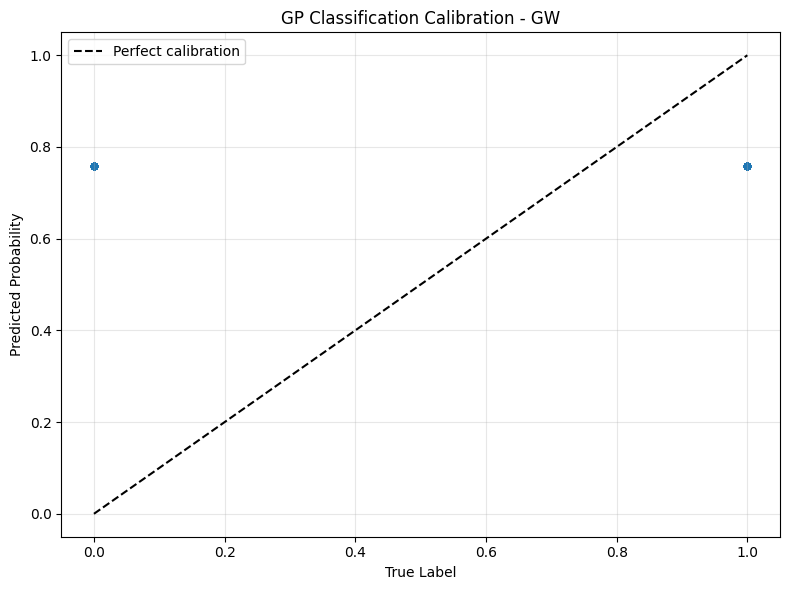

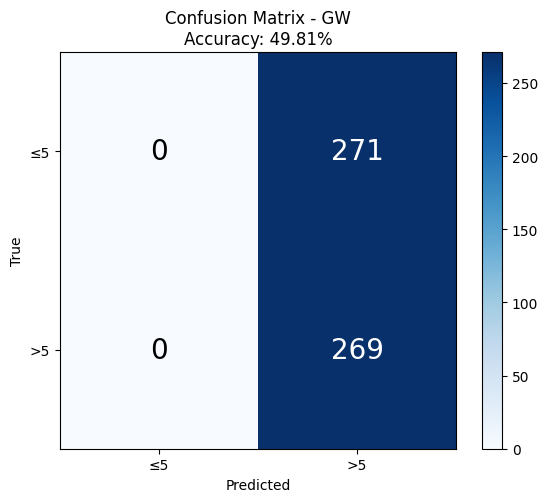

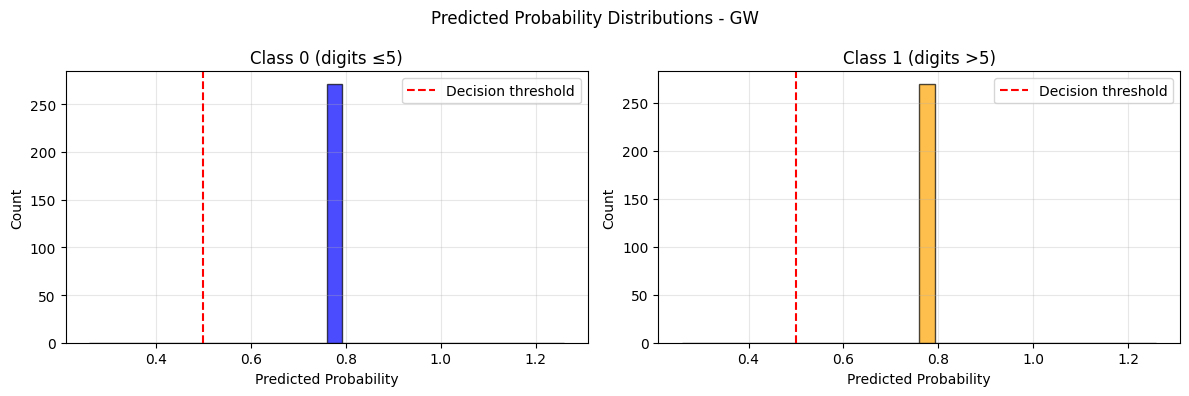

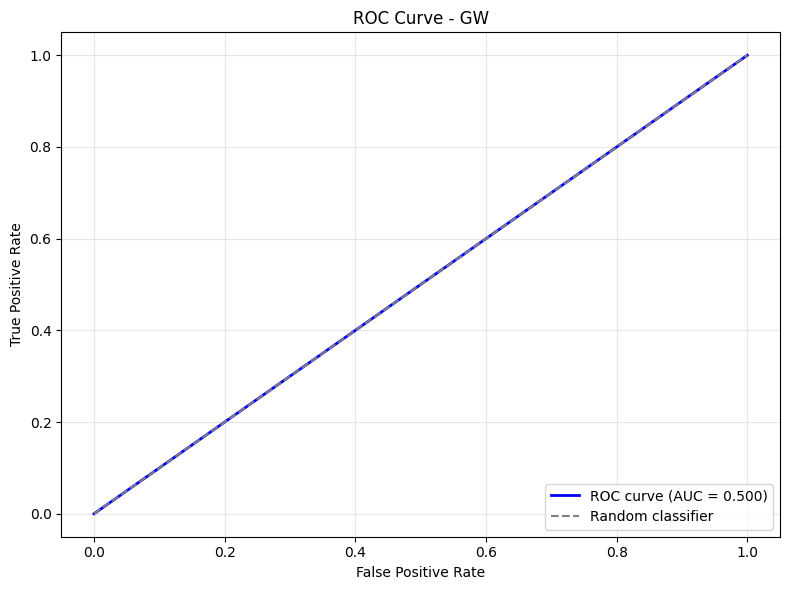

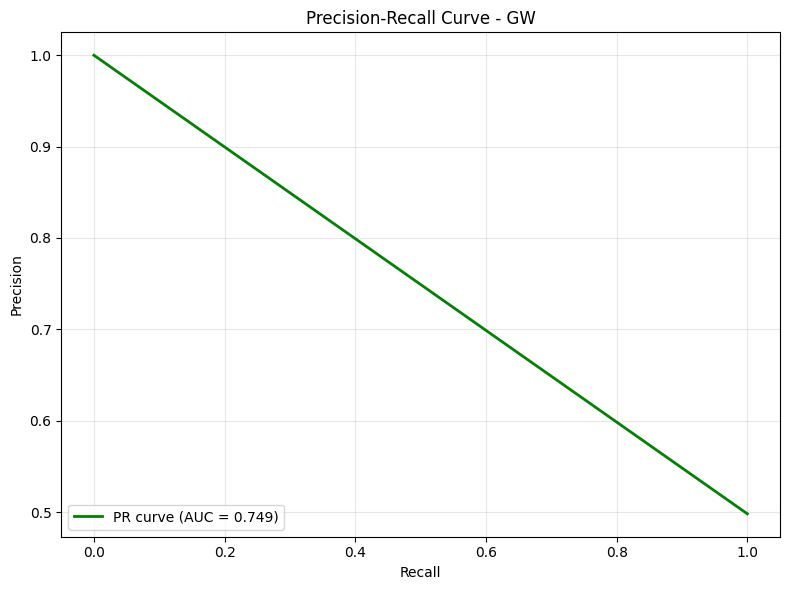

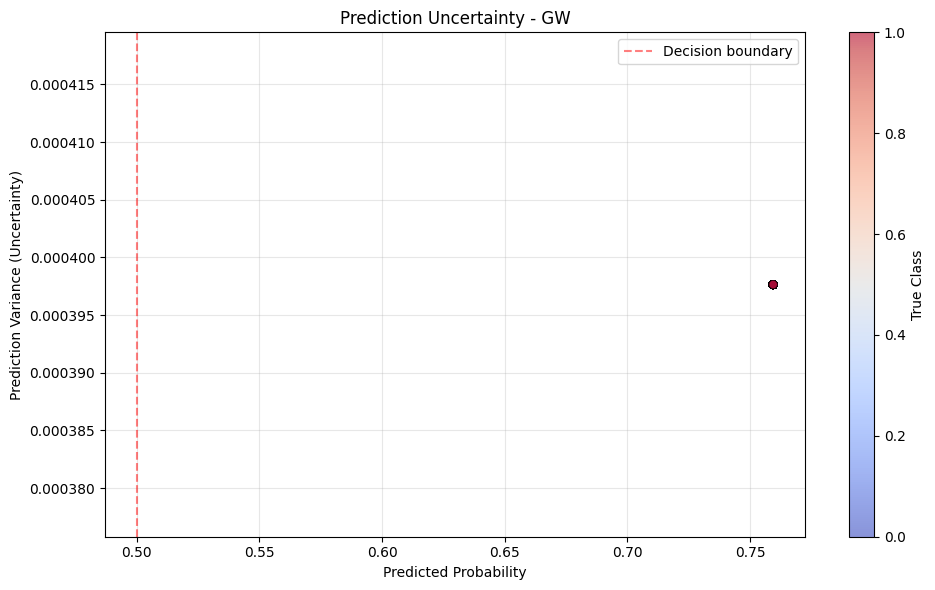

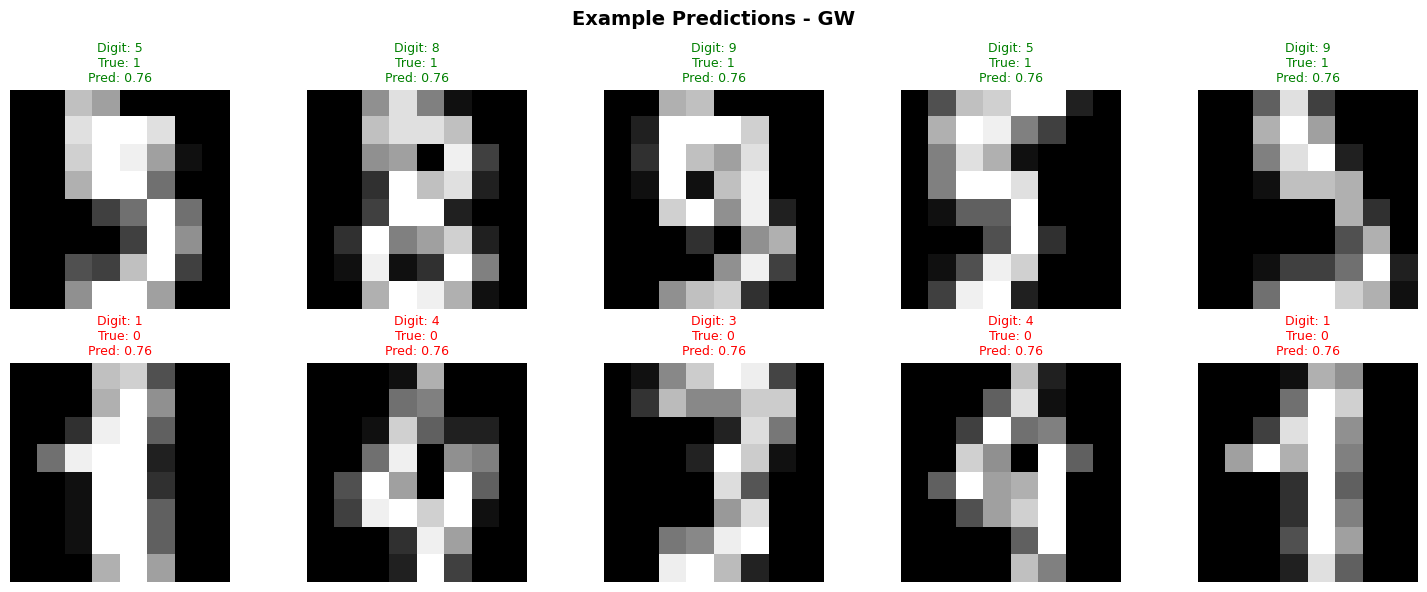


SUMMARY STATISTICS
Distance Metric: GW
Accuracy: 0.4981
Brier Score: 0.3183
ROC AUC: 0.5000
PR AUC: 0.7491

Predicted probabilities range: [0.759, 0.759]
Mean uncertainty (variance): 0.0004
Correct predictions: 269/540
Incorrect predictions: 271/540


In [59]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve
import numpy as np

# ===== 1. CALIBRATION PLOT =====
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_proba, alpha=0.5, s=20)
plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
plt.xlabel('True Label')
plt.ylabel('Predicted Probability')
plt.title(f'GP Classification Calibration - {DISTANCE_METRIC}')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ===== 2. CONFUSION MATRIX =====
cm = confusion_matrix(y_test, y_pred_class)
plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap='Blues', interpolation='nearest')
plt.colorbar()

# Add text annotations
for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm[i, j]), ha='center', va='center', 
                fontsize=20, color='white' if cm[i, j] > cm.max()/2 else 'black')

plt.xticks([0, 1], ['≤5', '>5'])
plt.yticks([0, 1], ['≤5', '>5'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Confusion Matrix - {DISTANCE_METRIC}\nAccuracy: {accuracy:.2%}')
plt.tight_layout()
plt.show()

# ===== 3. PROBABILITY DISTRIBUTIONS BY CLASS =====
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Class 0 (digits ≤5)
axes[0].hist(y_pred_proba[y_test == 0], bins=30, alpha=0.7, color='blue', edgecolor='black')
axes[0].axvline(0.5, color='red', linestyle='--', label='Decision threshold')
axes[0].set_xlabel('Predicted Probability')
axes[0].set_ylabel('Count')
axes[0].set_title('Class 0 (digits ≤5)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Class 1 (digits >5)
axes[1].hist(y_pred_proba[y_test == 1], bins=30, alpha=0.7, color='orange', edgecolor='black')
axes[1].axvline(0.5, color='red', linestyle='--', label='Decision threshold')
axes[1].set_xlabel('Predicted Probability')
axes[1].set_ylabel('Count')
axes[1].set_title('Class 1 (digits >5)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'Predicted Probability Distributions - {DISTANCE_METRIC}')
plt.tight_layout()
plt.show()

# ===== 4. ROC CURVE =====
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve - {DISTANCE_METRIC}')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ===== 5. PRECISION-RECALL CURVE =====
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
pr_auc = auc(recall, precision)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='green', lw=2, label=f'PR curve (AUC = {pr_auc:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'Precision-Recall Curve - {DISTANCE_METRIC}')
plt.legend(loc='lower left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ===== 6. UNCERTAINTY VISUALIZATION =====
plt.figure(figsize=(10, 6))
scatter = plt.scatter(y_pred_proba, var, c=y_test, cmap='coolwarm', 
                     alpha=0.6, edgecolors='black', linewidth=0.5)
plt.colorbar(scatter, label='True Class')
plt.xlabel('Predicted Probability')
plt.ylabel('Prediction Variance (Uncertainty)')
plt.title(f'Prediction Uncertainty - {DISTANCE_METRIC}')
plt.axvline(0.5, color='red', linestyle='--', alpha=0.5, label='Decision boundary')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ===== 7. SHOW EXAMPLE PREDICTIONS WITH ACTUAL IMAGES =====
# Get some correct and incorrect predictions
correct_idx = np.where(y_pred_class == y_test)[0]
incorrect_idx = np.where(y_pred_class != y_test)[0]

fig, axes = plt.subplots(2, 5, figsize=(15, 6))

# Show 5 correct predictions
for i, idx in enumerate(correct_idx[:5]):
    test_sample_idx = test_idx[idx]
    img = digits.images[test_sample_idx]
    true_digit = numerical_values[test_sample_idx]
    
    axes[0, i].imshow(img, cmap='gray')
    axes[0, i].set_title(f'Digit: {true_digit}\nTrue: {y_test[idx]}\n'
                         f'Pred: {y_pred_proba[idx]:.2f}', 
                         fontsize=9, color='green')
    axes[0, i].axis('off')

# Show 5 incorrect predictions
for i, idx in enumerate(incorrect_idx[:5] if len(incorrect_idx) >= 5 else incorrect_idx):
    test_sample_idx = test_idx[idx]
    img = digits.images[test_sample_idx]
    true_digit = numerical_values[test_sample_idx]
    
    axes[1, i].imshow(img, cmap='gray')
    axes[1, i].set_title(f'Digit: {true_digit}\nTrue: {y_test[idx]}\n'
                         f'Pred: {y_pred_proba[idx]:.2f}', 
                         fontsize=9, color='red')
    axes[1, i].axis('off')

# Hide empty subplots if not enough incorrect predictions
if len(incorrect_idx) < 5:
    for i in range(len(incorrect_idx), 5):
        axes[1, i].axis('off')

axes[0, 0].set_ylabel('CORRECT', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('INCORRECT', fontsize=12, fontweight='bold')

plt.suptitle(f'Example Predictions - {DISTANCE_METRIC}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ===== 8. SUMMARY STATISTICS =====
print("\n" + "="*70)
print("SUMMARY STATISTICS")
print("="*70)
print(f"Distance Metric: {DISTANCE_METRIC}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Brier Score: {brier_score:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")
print(f"PR AUC: {pr_auc:.4f}")
print(f"\nPredicted probabilities range: [{y_pred_proba.min():.3f}, {y_pred_proba.max():.3f}]")
print(f"Mean uncertainty (variance): {var.mean():.4f}")
print(f"Correct predictions: {np.sum(y_pred_class == y_test)}/{len(y_test)}")
print(f"Incorrect predictions: {np.sum(y_pred_class != y_test)}/{len(y_test)}")

In [ ]:
# Wass 2D:
# --------
# Distance Metric: Wass2D
# Accuracy: 0.7130
# Brier Score: 0.1507
# ROC AUC: 0.9986
# PR AUC: 0.9985

# Predicted probabilities range: [0.413, 0.904]
# Mean uncertainty (variance): 0.0181
# Correct predictions: 385/540
# Incorrect predictions: 155/540

##################################################
# Fused GW:
# ---------

# Distance Metric: FGW
# Accuracy: 0.7037
# Brier Score: 0.1575
# ROC AUC: 0.9984
# PR AUC: 0.9984

# Predicted probabilities range: [0.392, 0.899]
# Mean uncertainty (variance): 0.0406
# Correct predictions: 380/540
# Incorrect predictions: 160/540

##################################################
# Sliced Wass:
# ------------
# Distance Metric: sliced_Wass
# Accuracy: 0.7296
# Brier Score: 0.1547
# ROC AUC: 0.9962
# PR AUC: 0.9961

# Predicted probabilities range: [0.397, 0.909]
# Mean uncertainty (variance): 0.0171
# Correct predictions: 394/540
# Incorrect predictions: 146/540